In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt 
from IPython import display

In [3]:
def build_train_model(x,y):

    numepochs=500
    losses=torch.zeros(numepochs)

    ANNReg=nn.Sequential(
        nn.Linear(1,1),
        nn.ReLU(),
        nn.Linear(1,1)
    )

    lossfun=nn.MSELoss()
    optimizer=torch.optim.SGD(ANNReg.parameters(),lr=0.05)
    
    for epochi in range(numepochs):
        yHat=ANNReg(x)

        loss=lossfun(yHat,y)
        losses[epochi]=loss 

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    predictions=ANNReg(x)
    
    return predictions, losses




In [9]:
def create_data_and_outputs(m):
    N=50
    x=torch.randn(N,1)
    y=m*x + torch.randn(N,1)/2
    return x,y


In [12]:
slopes=np.linspace(-2,2,21)
numExps=50

results=np.zeros((len(slopes),numExps,2))

for slopei in range(len(slopes)):
    for N in range(numExps):
        x,y=create_data_and_outputs(slopes[slopei])
        yHat,losses=build_train_model(x,y)

        results[slopei,N,0]=losses[-1] 
        results[slopei,N,1]=np.corrcoef(y.T,yHat.detach().T)[0,1]

results[np.isnan(results)]=0


Text(0.5, 1.0, 'Model performance')

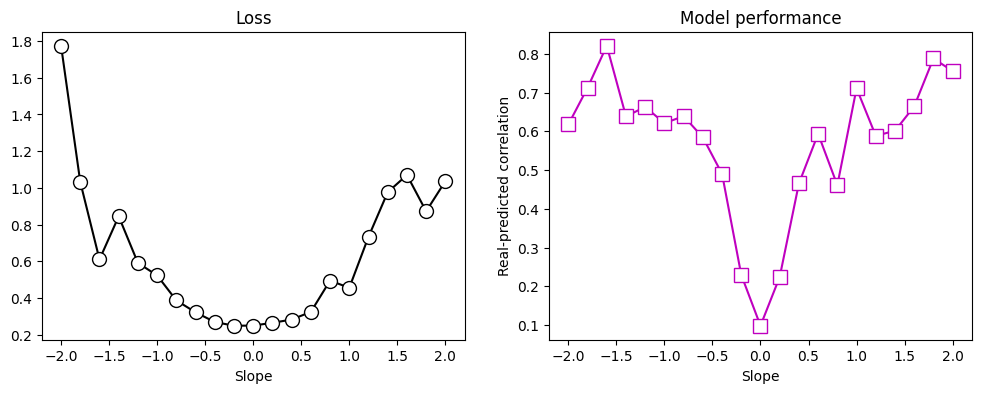

In [23]:
fig,ax=plt.subplots(1,2,figsize=(12,4))

ax[0].plot(slopes,np.mean(results[:,:,0],axis=1),'ko-',markerfacecolor='w',markersize=10)
ax[0].set_xlabel('Slope')
ax[0].set_title('Loss')

ax[1].plot(slopes,np.mean(results[:,:,1],axis=1),'ms-',markerfacecolor='w',markersize=10)
ax[1].set_xlabel('Slope')
ax[1].set_ylabel('Real-predicted correlation')
ax[1].set_title('Model performance')